In [6]:

from tsl.datasets import Elergone
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from matplotlib.pyplot import figure


### Preprocessing

In [ ]:
dataset = Elergone(root='./data')


In [ ]:
connectivity = dataset.get_connectivity(threshold=None,
                                        include_self=True,
                                        normalize_axis=1,
                                        layout="dense")


In [ ]:
print(f"Sampling period: {dataset.freq}")
print(f"Has missing values: {dataset.has_mask}")
print(f"Percentage of missing values: {(1 - dataset.mask.mean()) * 100:.2f}%")
print(f"Has exogenous variables: {dataset.has_covariates}")
print(f"Covariates: {', '.join(dataset.covariates.keys())}")

In [ ]:
df = dataset.dataframe()

In [ ]:
print(len(df))
df = df.resample('1h').sum()
print(len(df))

In [ ]:
all_val = df.values
T, V = all_val.shape
all_val = all_val.reshape(T, V, 1)

all_val.shape


In [ ]:

idx_intersection = -1


def has_zero_subarray(arr, min_length, eps=1e-9):
    
    # Count consecutive zeros
    max_zeros = 0
    current_zeros = 0
    
    for val in arr:
        if val < eps:
            current_zeros += 1
            max_zeros = max(max_zeros, current_zeros)
        else:
            current_zeros = 0
    
    return max_zeros >= min_length

# first cutoff after visual inspection
all_val_nz = all_val[10000:, :, :]

print(all_val_nz.shape)
node_idx_to_keep = []

for node_idx in range(all_val_nz.shape[1]):
    values = all_val_nz[:, node_idx, 0]
    if not has_zero_subarray(values, 72, np.mean(values) * 0.001): 
        node_idx_to_keep.append(node_idx)


all_val_nz = all_val_nz[:, node_idx_to_keep, :]

all_val_nz.shape

In [ ]:
connectivity = connectivity[np.ix_(node_idx_to_keep, node_idx_to_keep)]

connectivity.shape

In [ ]:

PLOT = True

rand_idx = np.random.randint(0, all_val_nz.shape[1], 50)


if PLOT:

    for node_idx in range(all_val_nz.shape[1]): 
        figure(figsize=(15,  6), dpi=80)
        plt.plot(all_val_nz[:, node_idx, 0])
        plt.title(f"Node {node_idx}")
        plt.show()

In [15]:
nodes_to_remove = set([
   0, 1, 2, 9, 11, 19, 20, 25, 29, 36, 57, 68, 79, 81, 83, 84, 85, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 99, 100, 101, 104, 105, 106, 107, 111, 112, 113, 121, 122,
   124, 125, 127, 128, 130, 144, 204, 281, 282, 283, 294, 300, 302, 305, 311, 313
])

nodes_to_keep = [i for i in range(all_val_nz.shape[1]) if i not in nodes_to_remove]

all_val_nz = all_val_nz[:, nodes_to_keep, :]
connectivity = connectivity[np.ix_(nodes_to_keep, nodes_to_keep)]

all_val_nz.shape, connectivity.shape

((25065, 261, 1), (261, 261))

In [17]:
threshold = np.quantile(connectivity.flatten(), 0.8)

adj = connectivity >= threshold

np.sum(adj) / adj.size

0.2000117438088108

In [2]:
DATA_PATH = '../diffstg/data/dataset/electricity_benchmark/'

# np.save(os.path.join(DATA_PATH, 'flow.npy'), all_val_nz)
# np.save(os.path.join(DATA_PATH, 'adj.npy'), adj)

In [7]:
adj = np.load(os.path.join(DATA_PATH, 'adj.npy'))

flow = np.load(os.path.join(DATA_PATH, 'flow.npy'))

adj.shape, flow.shape


((261, 261), (25065, 261, 1))

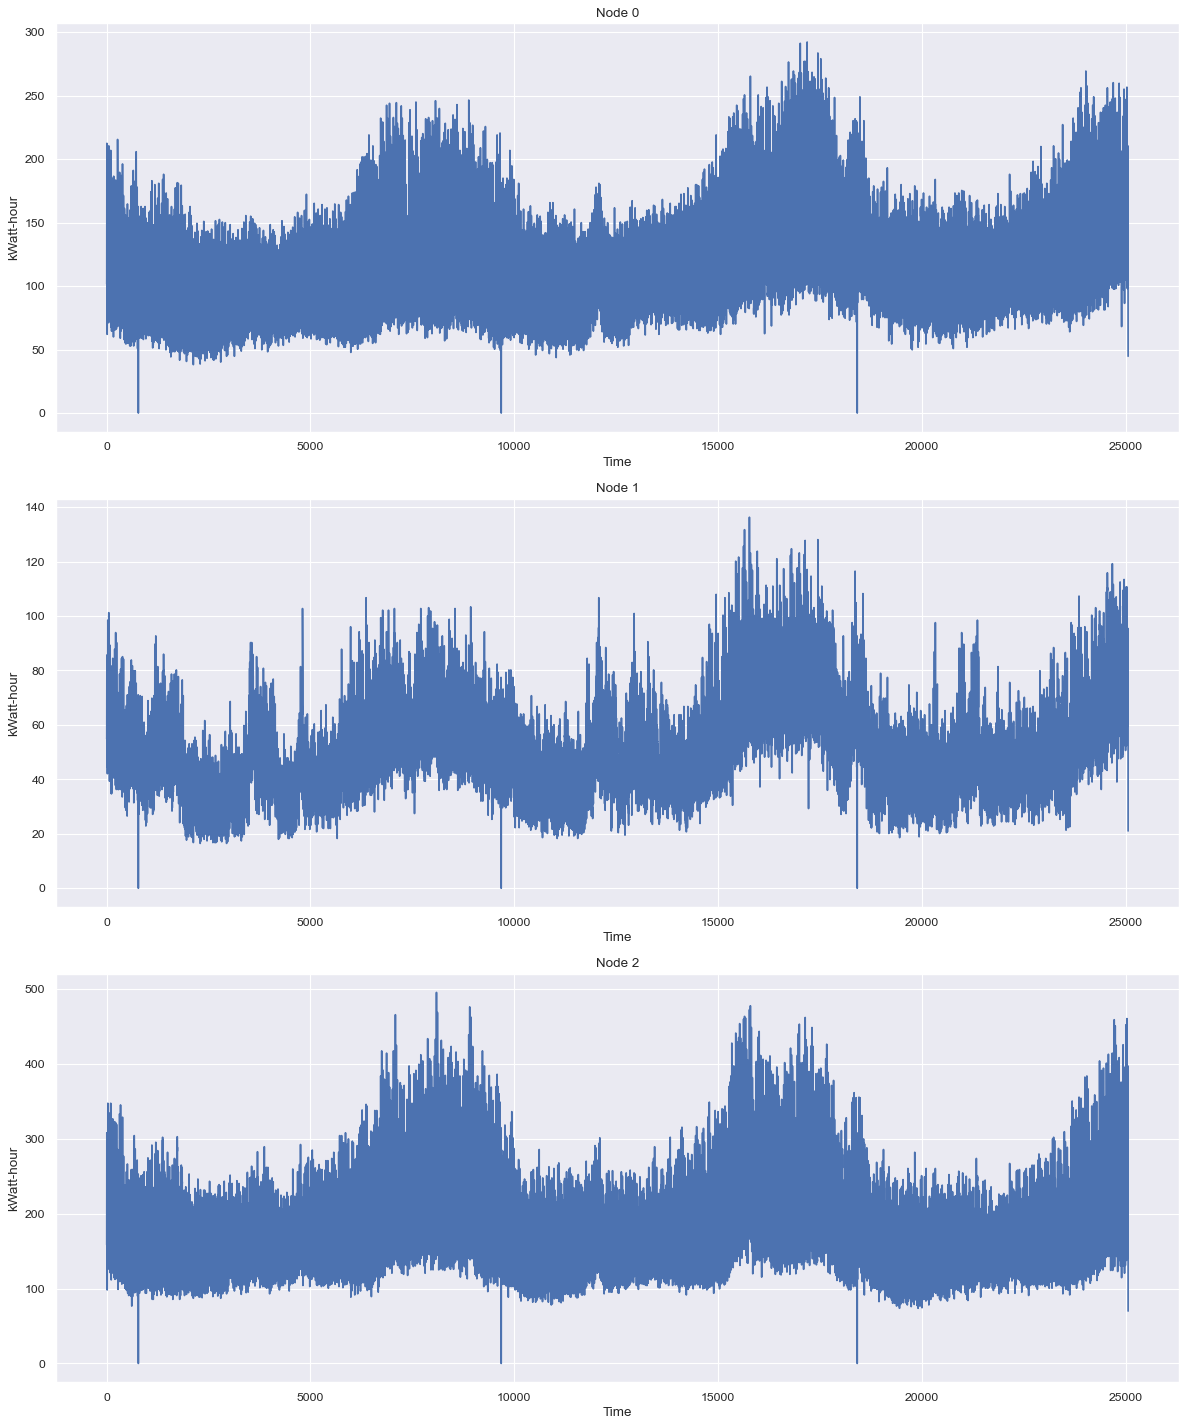

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(15, 18), dpi=80)

for node_idx in range(3):
    axes[node_idx].plot(flow[:, node_idx, 0])
    axes[node_idx].set_title(f"Node {node_idx}")
    axes[node_idx].set_xlabel("Time")
    axes[node_idx].set_ylabel("kWatt-hour")

plt.tight_layout()
plt.savefig('../diffstg/plot/elergone.pdf')
plt.show()